# Разработка алгоритма расчета состояния прибытия с учетом кэширования существующих подразделений

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox

ox.__version__

'2.0.1'

In [2]:
G = ox.load_graphml('C:/Users/obsid/Desktop/Диссертация/Расчеты/++Novosibirsk/data/gds.ml')

# Функции

In [ ]:
from itertools import count

from networkx import multi_source_dijkstra
from genesis.core import StateBase
from genesis.swiss_knife import DELAY_TIME, MSF
from genesis.tools import get_duplicates_list

from heapq import heappush, heappop


# def _dijkstra_multisource_cache(
#     G, sources, weight, pred=None, paths=None, cutoff=None, target=None, seen=None
# ):

#     G_succ = G._succ if G.is_directed() else G._adj

#     push = heappush
#     pop = heappop
#     dist = {}  # dictionary of final distances
#     # !!! передаем заранее как аргумент
#     # seen = {}
#     # fringe is heapq with 3-tuples (distance,c,node)
#     # use the count c to avoid comparing nodes (may not be able to)
#     c = count()
#     fringe = []
#     for source in sources:
#         if source not in G:
#             raise nx.NodeNotFound(f"Source {source} not in G")
#         seen[source] = 0
#         push(fringe, (0, next(c), source))
#     while fringe:
#         (d, _, v) = pop(fringe)
#         if v in dist:
#             continue  # already searched this node.
#         dist[v] = d
#         if v == target:
#             break
#         for u, e in G_succ[v].items():
#             cost = weight(v, u, e)
#             if cost is None:
#                 continue
#             vu_dist = dist[v] + cost
#             if cutoff is not None:
#                 if vu_dist > cutoff:
#                     continue
#             if u in dist:
#                 u_dist = dist[u]
#                 if vu_dist < u_dist:
#                     raise ValueError("Contradictory paths found:", "negative weights?")
#                 elif pred is not None and vu_dist == u_dist:
#                     pred[u].append(v)
#             elif u not in seen or vu_dist < seen[u]:
#                 seen[u] = vu_dist
#                 push(fringe, (vu_dist, next(c), u))
#                 if paths is not None:
#                     paths[u] = paths[v] + [u]
#                 if pred is not None:
#                     pred[u] = [v]
#             elif vu_dist == seen[u]:
#                 if pred is not None:
#                     pred[u].append(v)

#     # The optional predecessor and path dictionaries can be accessed
#     # by the caller via the pred and paths objects passed as arguments.
#     return dist

# def _weight_function_cache(G, weight):
#     """Returns a function that returns the weight of an edge.

#     The returned function is specifically suitable for input to
#     functions :func:`_dijkstra` and :func:`_bellman_ford_relaxation`.

#     Parameters
#     ----------
#     G : NetworkX graph.

#     weight : string or function
#         If it is callable, `weight` itself is returned. If it is a string,
#         it is assumed to be the name of the edge attribute that represents
#         the weight of an edge. In that case, a function is returned that
#         gets the edge weight according to the specified edge attribute.

#     Returns
#     -------
#     function
#         This function returns a callable that accepts exactly three inputs:
#         a node, an node adjacent to the first one, and the edge attribute
#         dictionary for the eedge joining those nodes. That function returns
#         a number representing the weight of an edge.

#     If `G` is a multigraph, and `weight` is not callable, the
#     minimum edge weight over all parallel edges is returned. If any edge
#     does not have an attribute with key `weight`, it is assumed to
#     have weight one.

#     """
#     if callable(weight):
#         return weight
#     # If the weight keyword argument is not callable, we assume it is a
#     # string representing the edge attribute containing the weight of
#     # the edge.
#     if G.is_multigraph():
#         return lambda u, v, d: min(attr.get(weight, 1) for attr in d.values())
#     return lambda u, v, data: data.get(weight, 1)


# def multi_source_dijkstra_cache(dists_cache):
#     def multi_source_dijkstra_cache_(G, sources, target=None, cutoff=None, weight="weight"):
#         """Find shortest weighted paths and lengths from a given set of
#         source nodes.

#         Uses Dijkstra's algorithm to compute the shortest paths and lengths
#         between one of the source nodes and the given `target`, or all other
#         reachable nodes if not specified, for a weighted graph.

#         Parameters
#         ----------
#         G : NetworkX graph

#         sources : non-empty set of nodes
#             Starting nodes for paths. If this is just a set containing a
#             single node, then all paths computed by this function will start
#             from that node. If there are two or more nodes in the set, the
#             computed paths may begin from any one of the start nodes.

#         target : node label, optional
#             Ending node for path

#         cutoff : integer or float, optional
#             Length (sum of edge weights) at which the search is stopped.
#             If cutoff is provided, only return paths with summed weight <= cutoff.

#         weight : string or function
#             If this is a string, then edge weights will be accessed via the
#             edge attribute with this key (that is, the weight of the edge
#             joining `u` to `v` will be ``G.edges[u, v][weight]``). If no
#             such edge attribute exists, the weight of the edge is assumed to
#             be one.

#             If this is a function, the weight of an edge is the value
#             returned by the function. The function must accept exactly three
#             positional arguments: the two endpoints of an edge and the
#             dictionary of edge attributes for that edge. The function must
#             return a number.

#         Returns
#         -------
#         distance, path : pair of dictionaries, or numeric and list
#             If target is None, returns a tuple of two dictionaries keyed by node.
#             The first dictionary stores distance from one of the source nodes.
#             The second stores the path from one of the sources to that node.
#             If target is not None, returns a tuple of (distance, path) where
#             distance is the distance from source to target and path is a list
#             representing the path from source to target.

#         Examples
#         --------
#         >>> G = nx.path_graph(5)
#         >>> length, path = nx.multi_source_dijkstra(G, {0, 4})
#         >>> for node in [0, 1, 2, 3, 4]:
#         ...     print(f"{node}: {length[node]}")
#         0: 0
#         1: 1
#         2: 2
#         3: 1
#         4: 0
#         >>> path[1]
#         [0, 1]
#         >>> path[3]
#         [4, 3]

#         >>> length, path = nx.multi_source_dijkstra(G, {0, 4}, 1)
#         >>> length
#         1
#         >>> path
#         [0, 1]

#         Notes
#         -----
#         Edge weight attributes must be numerical.
#         Distances are calculated as sums of weighted edges traversed.

#         The weight function can be used to hide edges by returning None.
#         So ``weight = lambda u, v, d: 1 if d['color']=="red" else None``
#         will find the shortest red path.

#         Based on the Python cookbook recipe (119466) at
#         https://code.activestate.com/recipes/119466/

#         This algorithm is not guaranteed to work if edge weights
#         are negative or are floating point numbers
#         (overflows and roundoff errors can cause problems).

#         Raises
#         ------
#         ValueError
#             If `sources` is empty.
#         NodeNotFound
#             If any of `sources` is not in `G`.

#         See Also
#         --------
#         multi_source_dijkstra_path
#         multi_source_dijkstra_path_length

#         """
#         if not sources:
#             raise ValueError("sources must not be empty")
#         if target in sources:
#             return (0, [target])
#         weight = _weight_function_cache(G, weight)

#         # makes copy of cache
#         # dists_copy = dists_cache  #.copy()

#         paths = {source: [source] for source in sources}  # dictionary of paths
#         dists = _dijkstra_multisource_cache(
#             G, sources, weight, paths=paths, cutoff=cutoff, target=target, seen=dists_cache
#         )

#         if target is None:
#             return (dists, paths)
#         try:
#             return (dists[target], paths[target])
#         except KeyError as e:
#             raise nx.NetworkXNoPath(f"No path to {target}.") from e
    
#     return multi_source_dijkstra_cache_
    




# g_nodes = list(G.nodes())
# static = {
#     g_nodes[1000]: 'псч 1',
#     g_nodes[2000]: 'псч 2',
# }
# dynamic = {g_nodes[3000]: 'псч 3'}


# times, paths = multi_source_dijkstra(G, sources=static.keys(), weight='travel_time')
# print(len(times), len(paths))
# times2, paths2 = multi_source_dijkstra_cache(seen=times)(G, sources=dynamic.keys(), weight='travel_time')
# print(len(times2), len(paths2))

In [ ]:
from genesis.states import FirstArrivalUnitState
from genesis.utils import timing

g_nodes = list(G.nodes())
static = {
    g_nodes[10000]: 'псч 1',
    g_nodes[2000]: 'псч 2',
    g_nodes[3500]: 'псч 3',
}
times, nearest = timing(FirstArrivalUnitState(multi_source_dijkstra))(env=G, points=static)
print(len(times), len(nearest))


ВРЕМЯ: 0.65 сек
43089 43089


In [44]:
dynamic = {
    g_nodes[5000]: 'псч 4',
    # g_nodes[6000]: 'псч 5',
    }
times2, nearest2 = timing(FirstArrivalUnitState(multi_source_dijkstra_cache(dists_cache=times)))(env=G, points=dynamic)
print(len(times2), len(nearest2))

times_total = times.copy()
times_total.update(times2)
print(np.mean(times_total))

# nx.set_node_attributes(G, nearest, 'nearest')
# nx.set_node_attributes(G, nearest2, 'nearest')
# nx.set_node_attributes(G, times, 'times')

ВРЕМЯ: 1.55 сек
25965 25965
15.724583398631157


In [51]:
dynamic = {
    g_nodes[5000]: 'псч 4',
    g_nodes[6000]: 'псч 5',
    }
times2, nearest2 = timing(FirstArrivalUnitState(multi_source_dijkstra_cache(dists_cache=times)))(env=G, points=dynamic)
print(len(times2), len(nearest2))

times_total = times.copy()
times_total.update(times2)
print(np.mean(times_total))

ВРЕМЯ: 1.61 сек
25965 25965
14.53548039539151


In [52]:
len(times_total)

43089

In [ ]:
nodes = ox.graph_to_gdfs(G, edges=False)
df = nodes.merge(times_total, left_index=True, right_index=True)

<Axes: >

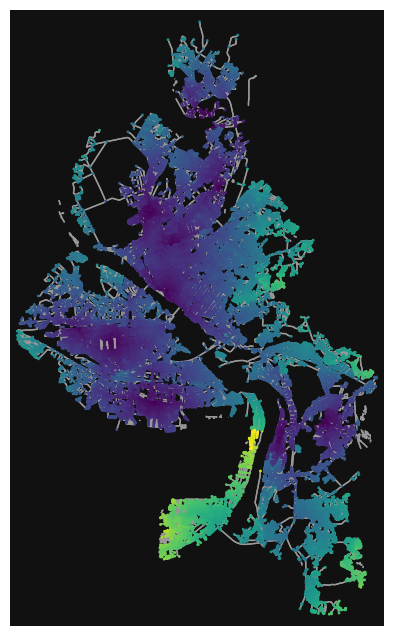

In [74]:
fig, ax = ox.plot_graph(G, node_size=0, close=False, show=False)
df.plot(column='times', markersize=1, ax=ax)

# Оценка времени расчета

In [97]:
g_nodes = list(G.nodes())
for i in range(10):
    static = {
        # random.choice(g_nodes): 'псч А1',
        g_nodes[1000]: 'псч 1',
        g_nodes[2000]: 'псч 2',
        g_nodes[3000]: 'псч 3',
        g_nodes[4000]: 'псч 4',
        g_nodes[5000]: 'псч 5',
        g_nodes[6000]: 'псч 6',
        g_nodes[7000]: 'псч 7',
        g_nodes[8000]: 'псч 8',
        g_nodes[9000]: 'псч 9',
        g_nodes[10000]: 'псч 10',
    }
    times, nearest = timing(FirstArrivalUnitState(multi_source_dijkstra))(env=G, points=static)

print(len(times), len(nearest))

ВРЕМЯ: 0.67 сек
ВРЕМЯ: 1.02 сек
ВРЕМЯ: 0.56 сек
ВРЕМЯ: 0.53 сек
ВРЕМЯ: 0.57 сек
ВРЕМЯ: 0.57 сек
ВРЕМЯ: 0.55 сек
ВРЕМЯ: 0.53 сек
ВРЕМЯ: 0.58 сек
ВРЕМЯ: 0.59 сек
43089 43089


In [100]:
import random

for i in range(30):
    dynamic = {
        random.choice(g_nodes): 'псч А1',
        random.choice(g_nodes): 'псч А2',
        # random.choice(g_nodes): 'псч А3',
        # random.choice(g_nodes): 'псч А4',
        # random.choice(g_nodes): 'псч А5',
        # random.choice(g_nodes): 'псч А6',
        # random.choice(g_nodes): 'псч А7',
        # random.choice(g_nodes): 'псч А8',
        }
    times2, nearest2 = timing(FirstArrivalUnitState(multi_source_dijkstra_cache(dists_cache=times.to_dict())))(env=G, points=dynamic)

    times_total = times.copy()
    times_total.update(times2)
    print(np.mean(times_total), len(times2))


ВРЕМЯ: 0.11 сек
10.185651199100292 6400
ВРЕМЯ: 0.09 сек
10.957114410964627 8183
ВРЕМЯ: 0.12 сек
11.22521380901388 9516
ВРЕМЯ: 0.06 сек
10.511600229111123 4960
ВРЕМЯ: 0.06 сек
11.277041851526194 5284
ВРЕМЯ: 0.08 сек
10.80308879137513 5588
ВРЕМЯ: 0.04 сек
11.259580014180894 4568
ВРЕМЯ: 0.07 сек
10.256991143791627 7187
ВРЕМЯ: 0.05 сек
11.100825903698633 4208
ВРЕМЯ: 0.07 сек
10.843614536541166 7029
ВРЕМЯ: 0.02 сек
11.275421286753232 1715
ВРЕМЯ: 0.05 сек
11.283461321730508 5227
ВРЕМЯ: 0.13 сек
10.772161467077343 11502
ВРЕМЯ: 0.07 сек
11.113103551949175 6221
ВРЕМЯ: 0.1 сек
11.2738578435506 6509
ВРЕМЯ: 0.06 сек
11.22051729803082 5343
ВРЕМЯ: 0.12 сек
9.967656083572164 10356
ВРЕМЯ: 0.02 сек
11.210956084403895 2251
ВРЕМЯ: 0.08 сек
10.303409219702255 7671
ВРЕМЯ: 0.04 сек
11.30153649659531 2895
ВРЕМЯ: 0.09 сек
10.973887718210742 9390
ВРЕМЯ: 0.05 сек
11.249667616565866 4004
ВРЕМЯ: 0.1 сек
11.36131908167295 9009
ВРЕМЯ: 0.04 сек
11.152331275950552 3069
ВРЕМЯ: 0.06 сек
11.064234299733508 3955
ВРЕМЯ: 0

**Вывод**: ни на одном из экспериментов время вычислений не превысило времени расчета для исходного

**При этом важно!** Перед передачей в алгоритм данные должны приводиться к типу `Dict`

Еще одно - чем больше ПСЧ, тем дольше расчет, что связано с тем, что большее количество узлов охватывается новыми ПСЧ

In [125]:
print('='*80)

# Алгоритм расчета состояния с кэшем

In [10]:
from itertools import count

from networkx import multi_source_dijkstra
from genesis.core import StateBase
from genesis.swiss_knife import DELAY_TIME, MSF
# from genesis.tools import get_duplicates_list

from heapq import heappush, heappop

class FirstArrivalUnitCacheState(StateBase):
    def __init__(self,
                 state_algorithm = MSF,
                 weight = 'travel_time',
                 delay = DELAY_TIME,
                 times_cache=None,
                 nearest_cache=None,
                 **kwargs):
        '''
            `state_algorithm`: function
                Функция расчета кратчайших путей от единственного источника. 
                В качестве функции могут быть переданы реализации алгоритмов из пакета
                `networkx`. Например, реализация алгоритма Дейкстры: `nx.multi_source_dijkstra`.
                Пользователь может использовать собственные функции с
                интерфейсом `func(G: Graph, sources: Any, target: Any | None = None, cutoff: Any | None = None, 
                                    weight: str = "weight") -> (dict, dict)`
            `weight`:str или callable  = "travel_time"
                Имя поля содержащего вес ребер, или функция позволяющая вычислять 
                вес динамически.
            `delay`: 
                Задержка в расчете. Например на обслуживание вызова на пожар.
                По умолчанию указана в swiss_knife.DELAY_TIME
        '''
        self.weight = weight
        self.delay = delay
        self.times_cache = times_cache
        self.nearest_cache = nearest_cache
        super().__init__(state_algorithm, **kwargs)

    def __call__(self,
                 env,
                 points,
                 area=None,
                 **kwargs):
        '''
        # Аргументы
        `env`: nx.MultiDiGraph (G)
            Граф улично-дорожной сети.
        `points`: list|dict (source)
            Стартовые узлы. Может быть списком узлов вида list(int), или словарем вида dict(int:str), где ключ - 
            идентификатор узла, значение - его наименование. Может использоваться для указания узлов в которых 
            расположены пожарные подразделения: {1234:'ПСЧ-1'}
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        

        # Возвращает
            times, nearest -> tuple[Series[float], Series[str] | Series]. 
            times - Время прибытия первого подразделения в каждый из узлов графа. 
            nearest - Соответствие узлов первому подразделению. 
        '''

        state_func = FirstArrivalUnitState(
            self.multi_source_dijkstra_cache(dists_cache=self.times_cache.to_dict()),
            weight = self.weight,
            delay  = self.delay
            )
        times, nearest = state_func(env=env, points=points, area=area, **kwargs)

        times_total = self.times_cache.copy()
        times_total.update(times)

        nearest_total = self.nearest_cache.copy()
        nearest_total.update(nearest)

        return times_total, nearest_total
    
    def _dijkstra_multisource_cache(
        self, G, sources, weight, pred=None, paths=None, cutoff=None, target=None, seen=None
    ):

        G_succ = G._succ if G.is_directed() else G._adj

        push = heappush
        pop = heappop
        dist = {}  # dictionary of final distances
        if seen is None:
            seen = {}
        # fringe is heapq with 3-tuples (distance,c,node)
        # use the count c to avoid comparing nodes (may not be able to)
        c = count()
        fringe = []
        for source in sources:
            if source not in G:
                raise nx.NodeNotFound(f"Source {source} not in G")
            seen[source] = 0
            push(fringe, (0, next(c), source))
        while fringe:
            (d, _, v) = pop(fringe)
            if v in dist:
                continue  # already searched this node.
            dist[v] = d
            if v == target:
                break
            for u, e in G_succ[v].items():
                cost = weight(v, u, e)
                if cost is None:
                    continue
                vu_dist = dist[v] + cost
                if cutoff is not None:
                    if vu_dist > cutoff:
                        continue
                if u in dist:
                    u_dist = dist[u]
                    if vu_dist < u_dist:
                        raise ValueError("Contradictory paths found:", "negative weights?")
                    elif pred is not None and vu_dist == u_dist:
                        pred[u].append(v)
                elif u not in seen or vu_dist < seen[u]:
                    seen[u] = vu_dist
                    push(fringe, (vu_dist, next(c), u))
                    if paths is not None:
                        paths[u] = paths[v] + [u]
                    if pred is not None:
                        pred[u] = [v]
                elif vu_dist == seen[u]:
                    if pred is not None:
                        pred[u].append(v)

        # The optional predecessor and path dictionaries can be accessed
        # by the caller via the pred and paths objects passed as arguments.
        return dist

    def _weight_function_cache(self, G, weight):
        """Returns a function that returns the weight of an edge.

        The returned function is specifically suitable for input to
        functions :func:`_dijkstra` and :func:`_bellman_ford_relaxation`.

        Parameters
        ----------
        G : NetworkX graph.

        weight : string or function
            If it is callable, `weight` itself is returned. If it is a string,
            it is assumed to be the name of the edge attribute that represents
            the weight of an edge. In that case, a function is returned that
            gets the edge weight according to the specified edge attribute.

        Returns
        -------
        function
            This function returns a callable that accepts exactly three inputs:
            a node, an node adjacent to the first one, and the edge attribute
            dictionary for the eedge joining those nodes. That function returns
            a number representing the weight of an edge.

        If `G` is a multigraph, and `weight` is not callable, the
        minimum edge weight over all parallel edges is returned. If any edge
        does not have an attribute with key `weight`, it is assumed to
        have weight one.

        """
        if callable(weight):
            return weight
        # If the weight keyword argument is not callable, we assume it is a
        # string representing the edge attribute containing the weight of
        # the edge.
        if G.is_multigraph():
            return lambda u, v, d: min(attr.get(weight, 1) for attr in d.values())
        return lambda u, v, data: data.get(weight, 1)


    def multi_source_dijkstra_cache(self, dists_cache):
        def multi_source_dijkstra_cache_(G, sources, target=None, cutoff=None, weight="weight"):
            """Find shortest weighted paths and lengths from a given set of
            source nodes.

            Uses Dijkstra's algorithm to compute the shortest paths and lengths
            between one of the source nodes and the given `target`, or all other
            reachable nodes if not specified, for a weighted graph.

            Parameters
            ----------
            G : NetworkX graph

            sources : non-empty set of nodes
                Starting nodes for paths. If this is just a set containing a
                single node, then all paths computed by this function will start
                from that node. If there are two or more nodes in the set, the
                computed paths may begin from any one of the start nodes.

            target : node label, optional
                Ending node for path

            cutoff : integer or float, optional
                Length (sum of edge weights) at which the search is stopped.
                If cutoff is provided, only return paths with summed weight <= cutoff.

            weight : string or function
                If this is a string, then edge weights will be accessed via the
                edge attribute with this key (that is, the weight of the edge
                joining `u` to `v` will be ``G.edges[u, v][weight]``). If no
                such edge attribute exists, the weight of the edge is assumed to
                be one.

                If this is a function, the weight of an edge is the value
                returned by the function. The function must accept exactly three
                positional arguments: the two endpoints of an edge and the
                dictionary of edge attributes for that edge. The function must
                return a number.

            Returns
            -------
            distance, path : pair of dictionaries, or numeric and list
                If target is None, returns a tuple of two dictionaries keyed by node.
                The first dictionary stores distance from one of the source nodes.
                The second stores the path from one of the sources to that node.
                If target is not None, returns a tuple of (distance, path) where
                distance is the distance from source to target and path is a list
                representing the path from source to target.

            Examples
            --------
            >>> G = nx.path_graph(5)
            >>> length, path = nx.multi_source_dijkstra(G, {0, 4})
            >>> for node in [0, 1, 2, 3, 4]:
            ...     print(f"{node}: {length[node]}")
            0: 0
            1: 1
            2: 2
            3: 1
            4: 0
            >>> path[1]
            [0, 1]
            >>> path[3]
            [4, 3]

            >>> length, path = nx.multi_source_dijkstra(G, {0, 4}, 1)
            >>> length
            1
            >>> path
            [0, 1]

            Notes
            -----
            Edge weight attributes must be numerical.
            Distances are calculated as sums of weighted edges traversed.

            The weight function can be used to hide edges by returning None.
            So ``weight = lambda u, v, d: 1 if d['color']=="red" else None``
            will find the shortest red path.

            Based on the Python cookbook recipe (119466) at
            https://code.activestate.com/recipes/119466/

            This algorithm is not guaranteed to work if edge weights
            are negative or are floating point numbers
            (overflows and roundoff errors can cause problems).

            Raises
            ------
            ValueError
                If `sources` is empty.
            NodeNotFound
                If any of `sources` is not in `G`.

            See Also
            --------
            multi_source_dijkstra_path
            multi_source_dijkstra_path_length

            """
            if not sources:
                raise ValueError("sources must not be empty")
            if target in sources:
                return (0, [target])
            weight = self._weight_function_cache(G, weight)

            paths = {source: [source] for source in sources}  # dictionary of paths
            dists = self._dijkstra_multisource_cache(
                G, sources, weight, paths=paths, cutoff=cutoff, target=target, seen=dists_cache
            )

            if target is None:
                return (dists, paths)
            try:
                return (dists[target], paths[target])
            except KeyError as e:
                raise nx.NetworkXNoPath(f"No path to {target}.") from e
        
        return multi_source_dijkstra_cache_



#==========================
static = {
        g_nodes[1000]: 'псч 1',
        g_nodes[2000]: 'псч 2',
        g_nodes[3000]: 'псч 3',
        g_nodes[4000]: 'псч 4',
        # g_nodes[5000]: 'псч 5',
        # g_nodes[6000]: 'псч 6',
        # g_nodes[7000]: 'псч 7',
        # g_nodes[8000]: 'псч 8',
        # g_nodes[9000]: 'псч 9',
        # g_nodes[10000]: 'псч 10',
    }
times, nearest = timing(FirstArrivalUnitState(multi_source_dijkstra))(env=G, points=static)
print(len(times), len(nearest))
print(times.describe())
print(' ')

dynamic = {
        random.choice(g_nodes): 'псч А1',
        random.choice(g_nodes): 'псч А2',
        # random.choice(g_nodes): 'псч А3',
        # random.choice(g_nodes): 'псч А4',
        # random.choice(g_nodes): 'псч А5',
        # random.choice(g_nodes): 'псч А6',
        # random.choice(g_nodes): 'псч А7',
        # random.choice(g_nodes): 'псч А8',
        }

# state_func = FirstArrivalUnitCacheState()
times2, nearest2 = timing(FirstArrivalUnitCacheState(
    times_cache=times, 
    nearest_cache=nearest)
    )(
    env=G, 
    points=dynamic, 
    )

print(len(times2), len(nearest2))
print(times2.describe())

ВРЕМЯ: 0.63 сек
43089 43089
count    43089.000000
mean        19.622618
std         14.020827
min          1.000000
25%          9.378520
50%         14.059073
75%         25.926997
max         65.586874
Name: times, dtype: float64
 
ВРЕМЯ: 0.16 сек
43089 43089
count    43089.000000
mean        13.342006
std          6.683395
min          1.000000
25%          8.288415
50%         11.996340
75%         17.580722
max         42.144385
Name: times, dtype: float64


In [12]:
g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)

g_nodes_gdf = g_nodes_gdf.merge(nearest, left_index=True, right_index=True)
g_nodes_gdf = g_nodes_gdf.merge(nearest2, left_index=True, right_index=True)
g_nodes_gdf.head(2)

,y,x,street_count,highway,geometry,nearest_x,nearest_y
178727045,55.121602,83.007775,3,NaN,POINT (83.00777 55.1216),псч 1,псч 1
178731745,55.102958,82.957801,3,NaN,POINT (82.9578 55.10296),псч 4,псч 4


<Axes: >

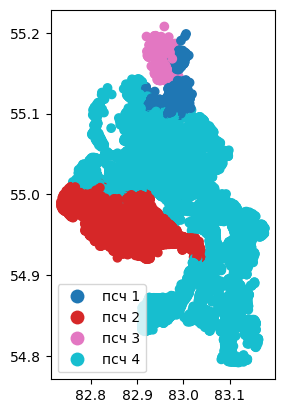

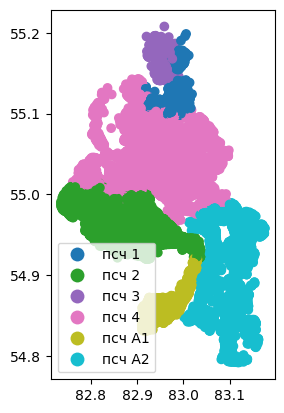

In [15]:
g_nodes_gdf.plot(column='nearest_x', legend=True)
g_nodes_gdf.plot(column='nearest_y', legend=True)

# Тесты с ГА

In [16]:
import random
from genesis.states import FirstArrivalUnitState
from genesis.utils import timing

In [17]:
g_nodes = list(G.nodes())

In [18]:
static = {
        g_nodes[1000]: 'псч 1',
        g_nodes[2000]: 'псч 2',
        g_nodes[3000]: 'псч 3',
        g_nodes[4000]: 'псч 4',
        g_nodes[5000]: 'псч 5',
        g_nodes[6000]: 'псч 6',
        g_nodes[7000]: 'псч 7',
        g_nodes[8000]: 'псч 8',
        g_nodes[9000]: 'псч 9',
        g_nodes[10000]: 'псч 10',
    }
times_cache, nearest_cache = timing(FirstArrivalUnitState(multi_source_dijkstra))(env=G, points=static)
print(len(times_cache), len(nearest_cache))
print(times_cache.describe())

ВРЕМЯ: 0.6 сек
43089 43089
count    43089.000000
mean        11.459020
std          6.998368
min          1.000000
25%          6.220746
50%          9.353310
75%         15.505444
max         41.486338
Name: times, dtype: float64


In [29]:
from genesis.mclp import BestNodesGA
from genesis.metrics import CoverIndex
from genesis.point_selectors import RandomNodesSelector


epochs_count = 5
pop          = 30

def iter_func(**kwargs):
    print(kwargs)

metric_func = CoverIndex()

selector_func = RandomNodesSelector()  #set(G.nodes()))


mclp_ga = timing(BestNodesGA(
    FirstArrivalUnitState(),
    metric_function    = metric_func,
    node_selector      = selector_func,
    population_size    = pop,
    epochs             = epochs_count,
    elite_size         = 10,
    mutation_max_count = 3,
    epoch_end_function = lambda **kwargs: print('*', end=''),
))

mclp_ga_cache = timing(BestNodesGA(
    FirstArrivalUnitCacheState(times_cache = times_cache, nearest_cache = nearest_cache),
    metric_function    = metric_func,
    node_selector      = selector_func,
    population_size    = pop,
    epochs             = epochs_count,
    elite_size         = 10,
    mutation_max_count = 3,
    epoch_end_function = lambda **kwargs: print('*', end=''),
))




dynamic = {
        random.choice(g_nodes): 'псч А1',
        random.choice(g_nodes): 'псч А2',
        random.choice(g_nodes): 'псч А3',
        # random.choice(g_nodes): 'псч А4',
        # random.choice(g_nodes): 'псч А5',
        # random.choice(g_nodes): 'псч А6',
        # random.choice(g_nodes): 'псч А7',
        # random.choice(g_nodes): 'псч А8',
        }

print('Расчет обычным ГА')
optimal_nodes, metric = mclp_ga(env=G, dynamic_nodes=dynamic, static_nodes=static)
print('')
print(metric)

print('Расчет кэшированным ГА')
optimal_nodes2, metric2 = mclp_ga_cache(env=G, dynamic_nodes=dynamic, )
print('')
print(metric2)



Расчет обычным ГА
*****ВРЕМЯ: 129.0 сек

66.9521223514122
Расчет кэшированным ГА
*****ВРЕМЯ: 32.12 сек

65.70818538374063


In [31]:
pop          = 50
epochs_count = 50
print('Сессий моделирования:', pop * epochs_count)

mclp_ga_cache = timing(BestNodesGA(
    FirstArrivalUnitCacheState(times_cache = times_cache, nearest_cache = nearest_cache),
    metric_function    = metric_func,
    node_selector      = selector_func,
    population_size    = pop,
    epochs             = epochs_count,
    elite_size         = 10,
    mutation_max_count = 3,
    epoch_end_function = lambda epoch, best_metric, **kwargs: print(epoch, best_metric, sep='\t'),
))

optimal_nodes3, metric3 = mclp_ga_cache(env=G, dynamic_nodes=dynamic, )
print('')
print(metric)

Сессий моделирования: 2500
0	62.03439392884495
1	63.714637146371466
2	64.20200051057114
3	66.1259254101975
4	66.1259254101975
5	66.1259254101975
6	66.51117454570772
7	66.51117454570772
8	66.8407250110237
9	66.97300935273503
10	66.97300935273503
11	69.03386014992225
12	69.03386014992225
13	69.03386014992225
14	69.03386014992225
15	69.03386014992225
16	69.74865975074844
17	69.74865975074844
18	69.74865975074844
19	69.74865975074844
20	70.03179465756922
21	70.20585300192624
22	70.20585300192624
23	70.20585300192624
24	70.20585300192624
25	70.20585300192624
26	70.20585300192624
27	70.20585300192624
28	70.20585300192624
29	70.52147879969365
30	70.52147879969365
31	70.52147879969365
32	70.52147879969365
33	70.52147879969365
34	70.52147879969365
35	70.52147879969365
36	70.52147879969365
37	70.52147879969365
38	70.52147879969365
39	70.52147879969365
40	70.52147879969365
41	70.52147879969365
42	70.52147879969365
43	70.52147879969365
44	70.52147879969365
45	70.52147879969365
46	70.52147879969365

# Задача LSCP

In [38]:
from genesis.lscp import LSCPCommon
from genesis.stop_cases import MoreEqualStopCase


mclp_ga_cache = BestNodesGA(
    FirstArrivalUnitCacheState(times_cache = times_cache, nearest_cache = nearest_cache),
    metric_function    = metric_func,
    node_selector      = selector_func,
    population_size    = 20,
    epochs             = 30,
    elite_size         = 10,
    mutation_max_count = 3,
    epoch_end_function = lambda epoch, best_metric, **kwargs: print(f'{epoch}: {best_metric}', end='\r'),
)

def after_mclp_func(iteration, best_metric, **kwargs):
    print(' ', iteration, best_metric, sep='\t')

lscp = LSCPCommon(
    mclp_ga_cache,
    point_selector      = selector_func,
    stop_case_function  = MoreEqualStopCase(95),
    metric_function     = metric_func,
    names_pattern       = 'псч new {}',
    start_names_index   = 100,
    after_mclp_function = after_mclp_func,
)

optimal_nodes4, metric4 = lscp(env=G, dynamic_nodes=dynamic, static_nodes=static)

******************************0	68.99672770312608
******************************1	72.65427371254845
******************************2	74.79171018125275
***********

KeyboardInterrupt: 